# 08 — Clinical outcome exploration

This notebook integrates clinical outcome metadata with molecular subtype and selected driver alteration data.

The goal is to explore whether molecular subtypes or selected genomic alterations show associations with overall survival or progression-free survival in TCGA-BRCA.

This analysis is exploratory and should not be interpreted as clinical validation.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test, logrank_test

pd.set_option("display.max_columns", 100)
sns.set_context("notebook")

In [2]:
PROJECT_ROOT = Path("..").resolve()

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
TABLES_DIR = PROJECT_ROOT / "results" / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

driver_path = PROCESSED_DIR / "multiomics_driver_alteration_table.tsv"
metadata_path = PROCESSED_DIR / "clinical_marker_analysis_table.tsv"

print("Driver table exists:", driver_path.exists())
print("Metadata exists:", metadata_path.exists())

Driver table exists: True
Metadata exists: True


In [3]:
driver_table = pd.read_csv(driver_path, sep="\t")
metadata = pd.read_csv(metadata_path, sep="\t")

print("driver_table:", driver_table.shape)
print("metadata:", metadata.shape)

display(driver_table.head())
display(metadata.head())

driver_table: (1082, 55)
metadata: (1082, 72)


,SAMPLE_ID_15,PATIENT_ID_12,SUBTYPE,TP53_mut,PIK3CA_mut,GATA3_mut,CDH1_mut,MAP3K1_mut,BRCA1_mut,BRCA2_mut,ERBB2_mut,MYC_mut,CCND1_mut,PTEN_mut,AKT1_mut,RB1_mut,TP53_amp,PIK3CA_amp,GATA3_amp,CDH1_amp,MAP3K1_amp,BRCA1_amp,BRCA2_amp,ERBB2_amp,MYC_amp,CCND1_amp,PTEN_amp,AKT1_amp,RB1_amp,TP53_del,PIK3CA_del,GATA3_del,CDH1_del,MAP3K1_del,BRCA1_del,BRCA2_del,ERBB2_del,MYC_del,CCND1_del,PTEN_del,AKT1_del,RB1_del,TP53_any_alt,PIK3CA_any_alt,GATA3_any_alt,CDH1_any_alt,MAP3K1_any_alt,BRCA1_any_alt,BRCA2_any_alt,ERBB2_any_alt,MYC_any_alt,CCND1_any_alt,PTEN_any_alt,AKT1_any_alt,RB1_any_alt
0,TCGA-3C-AAAU-01,TCGA-3C-AAAU,BRCA_LumA,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0
1,TCGA-3C-AALI-01,TCGA-3C-AALI,BRCA_Her2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
2,TCGA-3C-AALJ-01,TCGA-3C-AALJ,BRCA_LumB,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,0,0,0,0
3,TCGA-3C-AALK-01,TCGA-3C-AALK,BRCA_LumA,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0
4,TCGA-4H-AAAK-01,TCGA-4H-AAAK,BRCA_LumA,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0


,PATIENT_ID_sample,SAMPLE_ID,ONCOTREE_CODE,CANCER_TYPE,CANCER_TYPE_DETAILED,TUMOR_TYPE,GRADE,TISSUE_PROSPECTIVE_COLLECTION_INDICATOR,TISSUE_RETROSPECTIVE_COLLECTION_INDICATOR,TISSUE_SOURCE_SITE_CODE,TUMOR_TISSUE_SITE,ANEUPLOIDY_SCORE,SAMPLE_TYPE,MSI_SCORE_MANTIS,MSI_SENSOR_SCORE,SOMATIC_STATUS,TMB_NONSYNONYMOUS,TISSUE_SOURCE_SITE,TBL_SCORE,SAMPLE_ID_ORIGINAL_x,SAMPLE_ID_15,PATIENT_ID_12,PATIENT_ID_patient,SUBTYPE,CANCER_TYPE_ACRONYM,OTHER_PATIENT_ID,AGE,SEX,AJCC_PATHOLOGIC_TUMOR_STAGE,AJCC_STAGING_EDITION,DAYS_LAST_FOLLOWUP,DAYS_TO_BIRTH,DAYS_TO_INITIAL_PATHOLOGIC_DIAGNOSIS,ETHNICITY,FORM_COMPLETION_DATE,HISTORY_NEOADJUVANT_TRTYN,ICD_10,ICD_O_3_HISTOLOGY,ICD_O_3_SITE,INFORMED_CONSENT_VERIFIED,NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT,PATH_M_STAGE,PATH_N_STAGE,PATH_T_STAGE,PERSON_NEOPLASM_CANCER_STATUS,PRIMARY_LYMPH_NODE_PRESENTATION_ASSESSMENT,PRIOR_DX,RACE,RADIATION_THERAPY,WEIGHT,IN_PANCANPATHWAYS_FREEZE,OS_STATUS,OS_MONTHS,DSS_STATUS,DSS_MONTHS,DFS_STATUS,DFS_MONTHS,PFS_STATUS,PFS_MONTHS,GENETIC_ANCESTRY_LABEL,SAMPLE_ID_ORIGINAL_y,SAMPLE_ID_ORIGINAL,ESR1,PGR,ERBB2,MKI67,FOXA1,GATA3,TP53,PIK3CA,BRCA1,BRCA2
0,TCGA-3C-AAAU,TCGA-3C-AAAU-01,ILC,Breast Cancer,Breast Invasive Lobular Carcinoma,Infiltrating Lobular Carcinoma,NaN,No,Yes,3C,Breast,19.0,Primary,0.3319,0.55,Matched,0.800000,Columbia University,205.0,TCGA-3C-AAAU-01,TCGA-3C-AAAU-01,TCGA-3C-AAAU,TCGA-3C-AAAU,BRCA_LumA,BRCA,6E7D5EC6-A469-467C-B748-237353C23416,55,Female,STAGE X,6TH,4047.0,-20211.0,0,Not Hispanic Or Latino,1/13/14,No,C50.9,8520/3,C50.9,Yes,No,MX,NX,TX,With Tumor,Yes,No,White,No,NaN,Yes,0:LIVING,133.050597,0:ALIVE OR DEAD TUMOR FREE,133.050597,1:Recurred/Progressed,59.440444,1:PROGRESSION,59.440444,EUR,TCGA-3C-AAAU-01,TCGA-3C-AAAU-01,3457.9600,2273.2700,7113.41,2582.870,5448.37,14337.50,1385.530,487.003,831.317,178.878
1,TCGA-3C-AALI,TCGA-3C-AALI-01,IDC,Breast Cancer,Breast Invasive Ductal Carcinoma,Infiltrating Ductal Carcinoma,NaN,No,Yes,3C,Breast,22.0,Primary,0.3449,0.74,Matched,15.266667,Columbia University,190.0,TCGA-3C-AALI-01,TCGA-3C-AALI-01,TCGA-3C-AALI,TCGA-3C-AALI,BRCA_Her2,BRCA,55262FCB-1B01-4480-B322-36570430C917,50,Female,STAGE IIB,6TH,4005.0,-18538.0,0,Not Hispanic Or Latino,7/28/14,No,C50.9,8500/3,C50.9,Yes,No,M0,N1A,T2,Tumor Free,Yes,No,Black or African American,Yes,NaN,Yes,0:LIVING,131.669790,0:ALIVE OR DEAD TUMOR FREE,131.669790,0:DiseaseFree,131.669790,0:CENSORED,131.669790,AFR,TCGA-3C-AALI-01,TCGA-3C-AALI-01,68.5155,27.1887,194625.00,2285.480,6049.48,7437.74,414.356,321.914,389.886,153.888
2,TCGA-3C-AALJ,TCGA-3C-AALJ-01,IDC,Breast Cancer,Breast Invasive Ductal Carcinoma,Infiltrating Ductal Carcinoma,NaN,No,Yes,3C,Breast,13.0,Primary,0.3266,0.31,Matched,0.933333,Columbia University,365.0,TCGA-3C-AALJ-01,TCGA-3C-AALJ-01,TCGA-3C-AALJ,TCGA-3C-AALJ,BRCA_LumB,BRCA,427D0648-3F77-4FFC-B52C-89855426D647,62,Female,STAGE IIB,7TH,1474.0,-22848.0,0,Not Hispanic Or Latino,7/28/14,No,C50.9,8500/3,C50.9,Yes,No,M0,N1A,T2,Tumor Free,Yes,No,Black or African American,No,NaN,Yes,0:LIVING,48.459743,0:ALIVE OR DEAD TUMOR FREE,48.459743,0:DiseaseFree,48.459743,0:CENSORED,48.459743,AFR_ADMIX,TCGA-3C-AALJ-01,TCGA-3C-AALJ-01,7482.3200,473.8350,11070.70,949.229,4620.13,10252.90,1289.210,216.682,200.363,151.405
3,TCGA-3C-AALK,TCGA-3C-AALK-01,IDC,Breast Cancer,Breast Invasive Ductal Carcinoma,Infiltrating Ductal Carcinoma,NaN,No,Yes,3C,Breast,4.0,Primary,0.3218,0.03,Matched,1.500000,Columbia University,25.0,TCGA-3C-AALK-01,TCGA-3C-AALK-01,TCGA-3C-AALK,TCGA-3C-AALK,BRCA_LumA,BRCA,C31900A4-5DCD-4022-97AC-638E86E889E4,52,Female,STAGE IA,7TH,1448.0,-19074.0,0,Not Hispanic Or Latino,7/28/14,No,C50.9,8500/3,C50.9,Yes,No,M0,N0 (I+),T1C,Tumor Free,Yes,No,Black or African American,No,NaN,Yes,0:LIVING,47.604958,0:ALIVE OR DEAD TUMOR FREE,47.604958,NaN,NaN,0:CENSORED,47.604958,AFR,TCGA-3C-AALK-01,TCGA-3C-AALK-01,2485.3100,2236.4600,36022.80,1139.430,7352.09,8761.69,1418.290,326.024,148.118,102.193
4,TCGA-4H-AAAK,TCGA-4H-AAAK-01,ILC,Breast Cancer,Breast Invasive Lobular Carcinoma,

In [4]:
clinical_keywords = [
    "OS",
    "PFS",
    "DFS",
    "SURVIVAL",
    "STATUS",
    "MONTHS",
    "STAGE",
    "AGE",
    "TUMOR",
]

clinical_candidates = [
    col for col in metadata.columns
    if any(k in col.upper() for k in clinical_keywords)
]

display(pd.DataFrame({"clinical_candidate_column": clinical_candidates}))

for col in clinical_candidates:
    if metadata[col].nunique(dropna=True) <= 20:
        print(f"\n{col}")
        display(metadata[col].value_counts(dropna=False).head(20))

,clinical_candidate_column
0,TUMOR_TYPE
1,TISSUE_PROSPECTIVE_COLLECTION_INDICATOR
2,TISSUE_RETROSPECTIVE_COLLECTION_INDICATOR
3,TUMOR_TISSUE_SITE
4,SOMATIC_STATUS
5,AGE
6,AJCC_PATHOLOGIC_TUMOR_STAGE
7,DAYS_TO_INITIAL_PATHOLOGIC_DIAGNOSIS
8,NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT
9,PATH_M_STAGE



TUMOR_TYPE


TUMOR_TYPE
Infiltrating Ductal Carcinoma     774
Infiltrating Lobular Carcinoma    201
Other                              45
Mixed Histology (NOS)              29
Mucinous Carcinoma                 17
Metaplastic Carcinoma               8
Medullary Carcinoma                 6
Infiltrating Carcinoma (NOS)        1
Breast Invasive Carcinoma           1
Name: count, dtype: int64


TISSUE_PROSPECTIVE_COLLECTION_INDICATOR


TISSUE_PROSPECTIVE_COLLECTION_INDICATOR
No     719
Yes    359
NaN      4
Name: count, dtype: int64

...

DSS_STATUS
0:ALIVE OR DEAD TUMOR FREE    979
1:DEAD WITH TUMOR              83
NaN                            20
Name: count, dtype: int64


DFS_STATUS


DFS_STATUS
0:DiseaseFree            856
NaN                      142
1:Recurred/Progressed     84
Name: count, dtype: int64


PFS_STATUS


PFS_STATUS
0:CENSORED       936
1:PROGRESSION    145
NaN                1
Name: count, dtype: int64

In [5]:
id_cols = ["SAMPLE_ID_15", "PATIENT_ID_12"]

clinical_cols = [
    "SUBTYPE",
    "OS_STATUS",
    "OS_MONTHS",
    "PFS_STATUS",
    "PFS_MONTHS",
    "DFS_STATUS",
    "DFS_MONTHS",
    "AGE",
    "AJCC_PATHOLOGIC_TUMOR_STAGE",
]

clinical_cols = [col for col in clinical_cols if col in metadata.columns]

clinical = metadata[id_cols + clinical_cols].drop_duplicates(subset=id_cols).copy()

df = driver_table.merge(
    clinical,
    on=id_cols + ["SUBTYPE"],
    how="left"
)

print("Integrated clinical-molecular table:", df.shape)
display(df.head())

Integrated clinical-molecular table: (1082, 63)


,SAMPLE_ID_15,PATIENT_ID_12,SUBTYPE,TP53_mut,PIK3CA_mut,GATA3_mut,CDH1_mut,MAP3K1_mut,BRCA1_mut,BRCA2_mut,ERBB2_mut,MYC_mut,CCND1_mut,PTEN_mut,AKT1_mut,RB1_mut,TP53_amp,PIK3CA_amp,GATA3_amp,CDH1_amp,MAP3K1_amp,BRCA1_amp,BRCA2_amp,ERBB2_amp,MYC_amp,CCND1_amp,PTEN_amp,AKT1_amp,RB1_amp,TP53_del,PIK3CA_del,GATA3_del,CDH1_del,MAP3K1_del,BRCA1_del,BRCA2_del,ERBB2_del,MYC_del,CCND1_del,PTEN_del,AKT1_del,RB1_del,TP53_any_alt,PIK3CA_any_alt,GATA3_any_alt,CDH1_any_alt,MAP3K1_any_alt,BRCA1_any_alt,BRCA2_any_alt,ERBB2_any_alt,MYC_any_alt,CCND1_any_alt,PTEN_any_alt,AKT1_any_alt,RB1_any_alt,OS_STATUS,OS_MONTHS,PFS_STATUS,PFS_MONTHS,DFS_STATUS,DFS_MONTHS,AGE,AJCC_PATHOLOGIC_TUMOR_STAGE
0,TCGA-3C-AAAU-01,TCGA-3C-AAAU,BRCA_LumA,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0:LIVING,133.050597,1:PROGRESSION,59.440444,1:Recurred/Progressed,59.440444,55,STAGE X
1,TCGA-3C-AALI-01,TCGA-3C-AALI,BRCA_Her2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0:LIVING,131.669790,0:CENSORED,131.669790,0:DiseaseFree,131.669790,50,STAGE IIB
2,TCGA-3C-AALJ-01,TCGA-3C-AALJ,BRCA_LumB,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0:LIVING,48.459743,0:CENSORED,48.459743,0:DiseaseFree,48.459743,62,STAGE IIB
3,TCGA-3C-AALK-01,TCGA-3C-AALK,BRCA_LumA,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0:LIVING,47.604958,0:CENSORED,47.604958,NaN,NaN,52,STAGE IA
4,TCGA-4H-AAAK-01,TCGA-4H-AAAK,BRCA_LumA,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0:LIVING,11.440971,0:CENSORED,11.440971,0:DiseaseFree,11.440971,50,STAGE IIIA


In [6]:
def parse_event(status):
    if pd.isna(status):
        return np.nan
    
    status = str(status).strip().upper()
    
    if status.startswith("1"):
        return 1
    
    if status.startswith("0"):
        return 0
    
    positive_words = ["DECEASED", "DEAD", "PROGRESSION", "RECURRED", "EVENT"]
    negative_words = ["LIVING", "ALIVE", "CENSORED", "DISEASEFREE", "DISEASE FREE"]
    
    if any(word in status for word in positive_words):
        return 1
    
    if any(word in status for word in negative_words):
        return 0
    
    return np.nan


if "OS_STATUS" in df.columns:
    df["OS_EVENT"] = df["OS_STATUS"].apply(parse_event)

if "PFS_STATUS" in df.columns:
    df["PFS_EVENT"] = df["PFS_STATUS"].apply(parse_event)

if "DFS_STATUS" in df.columns:
    df["DFS_EVENT"] = df["DFS_STATUS"].apply(parse_event)

outcome_cols = [
    col for col in ["OS_STATUS", "OS_MONTHS", "OS_EVENT", "PFS_STATUS", "PFS_MONTHS", "PFS_EVENT", "DFS_STATUS", "DFS_MONTHS", "DFS_EVENT"]
    if col in df.columns
]

display(df[["SUBTYPE"] + outcome_cols].head())

,SUBTYPE,OS_STATUS,OS_MONTHS,OS_EVENT,PFS_STATUS,PFS_MONTHS,PFS_EVENT,DFS_STATUS,DFS_MONTHS,DFS_EVENT
0,BRCA_LumA,0:LIVING,133.050597,0,1:PROGRESSION,59.440444,1.0,1:Recurred/Progressed,59.440444,1.0
1,BRCA_Her2,0:LIVING,131.669790,0,0:CENSORED,131.669790,0.0,0:DiseaseFree,131.669790,0.0
2,BRCA_LumB,0:LIVING,48.459743,0,0:CENSORED,48.459743,0.0,0:DiseaseFree,48.459743,0.0
3,BRCA_LumA,0:LIVING,47.604958,0,0:CENSORED,47.604958,0.0,NaN,NaN,NaN
4,BRCA_LumA,0:LIVING,11.440971,0,0:CENSORED,11.440971,0.0,0:DiseaseFree,11.440971,0.0


In [7]:
summary_rows = []

for duration_col, event_col in [
    ("OS_MONTHS", "OS_EVENT"),
    ("PFS_MONTHS", "PFS_EVENT"),
    ("DFS_MONTHS", "DFS_EVENT"),
]:
    if duration_col in df.columns and event_col in df.columns:
        tmp = df[[duration_col, event_col]].copy()
        tmp[duration_col] = pd.to_numeric(tmp[duration_col], errors="coerce")
        tmp = tmp.dropna()
        
        summary_rows.append({
            "outcome": duration_col.replace("_MONTHS", ""),
            "n_samples_with_data": tmp.shape[0],
            "n_events": int(tmp[event_col].sum()),
            "median_followup_months": tmp[duration_col].median(),
            "max_followup_months": tmp[duration_col].max(),
        })

outcome_summary = pd.DataFrame(summary_rows)

display(outcome_summary)

outcome_summary.to_csv(TABLES_DIR / "clinical_outcome_availability_summary.csv", index=False)

,outcome,n_samples_with_data,n_events,median_followup_months,max_followup_months
0,OS,1082,151,27.073676,282.901009
1,PFS,1080,145,25.166847,281.290068
2,DFS,939,84,24.986028,281.290068


In [8]:
def plot_km_by_group(
    df,
    duration_col,
    event_col,
    group_col,
    title,
    filename,
    min_group_size=20,
):
    required = [duration_col, event_col, group_col]
    plot_df = df[required].copy()
    
    plot_df[duration_col] = pd.to_numeric(plot_df[duration_col], errors="coerce")
    plot_df = plot_df.dropna()
    
    counts = plot_df[group_col].value_counts()
    valid_groups = counts[counts >= min_group_size].index.tolist()
    plot_df = plot_df[plot_df[group_col].isin(valid_groups)].copy()
    
    if plot_df[group_col].nunique() < 2:
        print(f"Not enough groups for {group_col}")
        return None
    
    kmf = KaplanMeierFitter()
    
    plt.figure(figsize=(7, 5))
    
    for group in valid_groups:
        group_df = plot_df[plot_df[group_col] == group]
        
        kmf.fit(
            durations=group_df[duration_col],
            event_observed=group_df[event_col],
            label=f"{group} (n={len(group_df)})",
        )
        
        kmf.plot_survival_function(ci_show=False)
    
    plt.title(title)
    plt.xlabel("Months")
    plt.ylabel("Survival probability")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / filename, dpi=300)
    plt.show()
    
    result = multivariate_logrank_test(
        plot_df[duration_col],
        plot_df[group_col],
        plot_df[event_col],
    )
    
    print("Log-rank p-value:", result.p_value)
    
    return plot_df

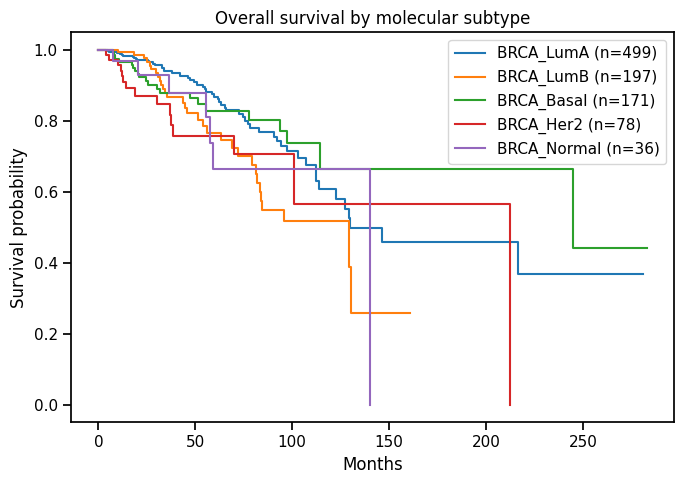

Log-rank p-value: 0.02397771328936186


In [9]:
if {"OS_MONTHS", "OS_EVENT", "SUBTYPE"}.issubset(df.columns):
    os_by_subtype = plot_km_by_group(
        df=df,
        duration_col="OS_MONTHS",
        event_col="OS_EVENT",
        group_col="SUBTYPE",
        title="Overall survival by molecular subtype",
        filename="overall_survival_by_subtype.png",
        min_group_size=20,
    )

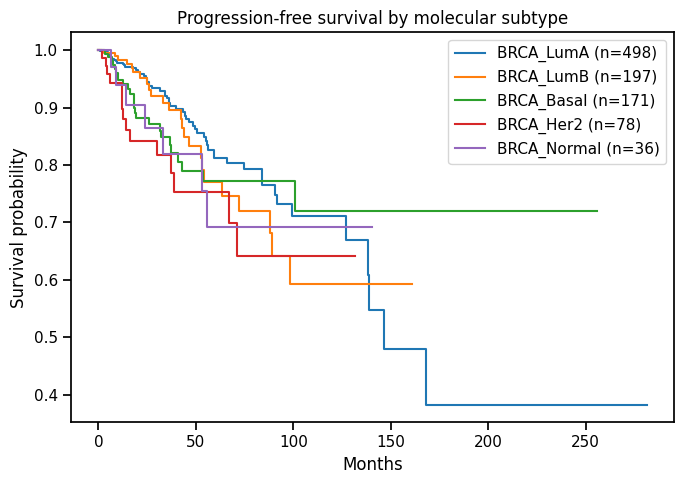

Log-rank p-value: 0.13207316691198917


In [10]:
if {"PFS_MONTHS", "PFS_EVENT", "SUBTYPE"}.issubset(df.columns):
    pfs_by_subtype = plot_km_by_group(
        df=df,
        duration_col="PFS_MONTHS",
        event_col="PFS_EVENT",
        group_col="SUBTYPE",
        title="Progression-free survival by molecular subtype",
        filename="progression_free_survival_by_subtype.png",
        min_group_size=20,
    )

In [11]:
def plot_binary_km(
    df,
    duration_col,
    event_col,
    alteration_col,
    title,
    filename,
    min_group_size=20,
):
    required = [duration_col, event_col, alteration_col]
    plot_df = df[required].copy()
    
    plot_df[duration_col] = pd.to_numeric(plot_df[duration_col], errors="coerce")
    plot_df = plot_df.dropna()
    plot_df[alteration_col] = plot_df[alteration_col].astype(int)
    
    counts = plot_df[alteration_col].value_counts()
    
    if not set([0, 1]).issubset(counts.index):
        print(f"{alteration_col}: both groups not present.")
        return None
    
    if counts.min() < min_group_size:
        print(f"{alteration_col}: one group has fewer than {min_group_size} samples.")
        display(counts)
        return None
    
    labels = {
        0: f"{alteration_col}=0",
        1: f"{alteration_col}=1",
    }
    
    kmf = KaplanMeierFitter()
    
    plt.figure(figsize=(7, 5))
    
    for value in [0, 1]:
        group_df = plot_df[plot_df[alteration_col] == value]
        
        kmf.fit(
            durations=group_df[duration_col],
            event_observed=group_df[event_col],
            label=f"{labels[value]} (n={len(group_df)})",
        )
        
        kmf.plot_survival_function(ci_show=False)
    
    plt.title(title)
    plt.xlabel("Months")
    plt.ylabel("Survival probability")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / filename, dpi=300)
    plt.show()
    
    g0 = plot_df[plot_df[alteration_col] == 0]
    g1 = plot_df[plot_df[alteration_col] == 1]
    
    result = logrank_test(
        g0[duration_col],
        g1[duration_col],
        event_observed_A=g0[event_col],
        event_observed_B=g1[event_col],
    )
    
    print("Log-rank p-value:", result.p_value)
    
    return plot_df


TP53_mut


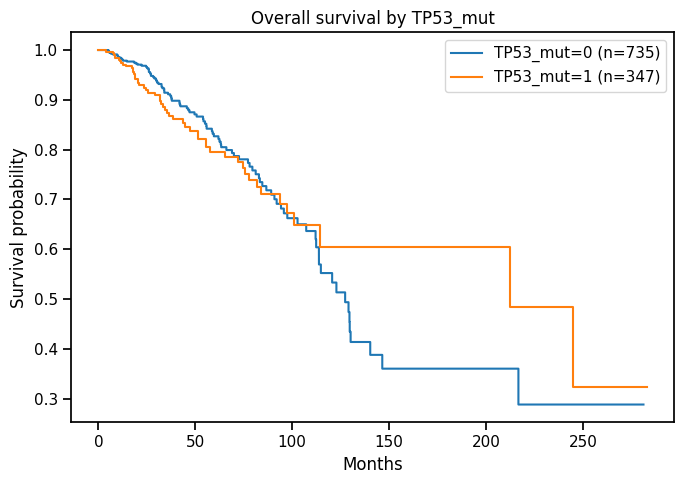

Log-rank p-value: 0.7524550628185259

PIK3CA_mut


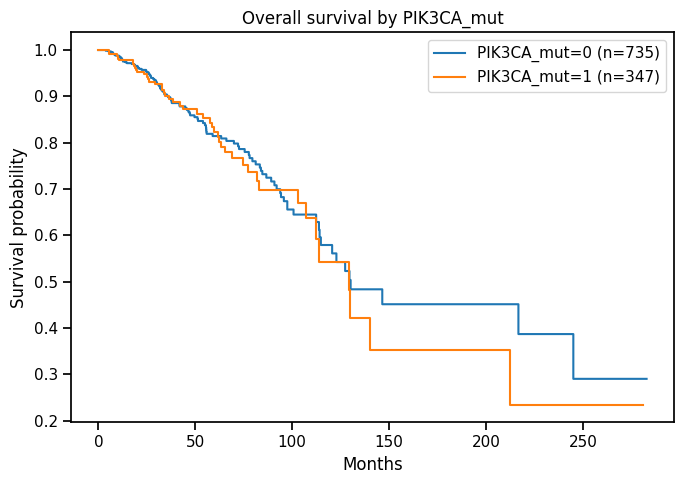

Log-rank p-value: 0.6926687898831999

ERBB2_amp


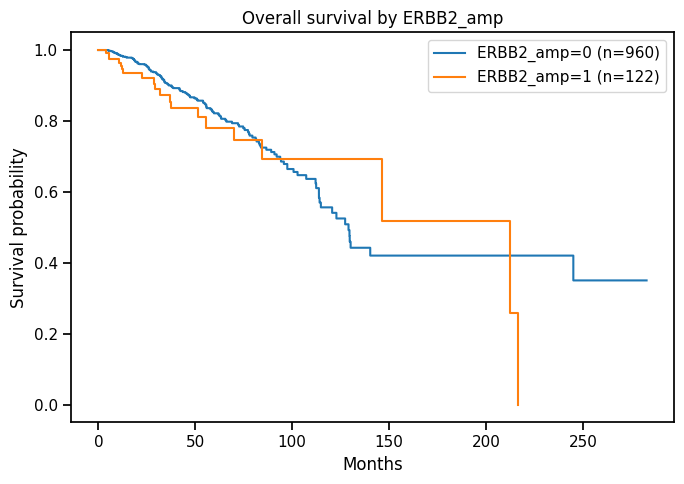

Log-rank p-value: 0.31159211250734126

CCND1_amp


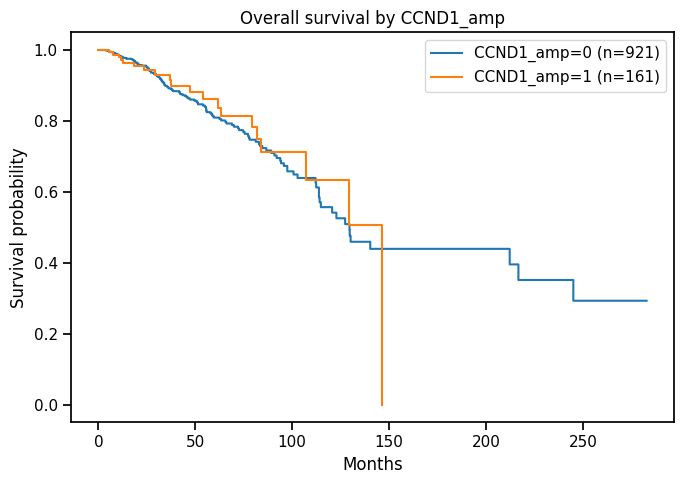

Log-rank p-value: 0.7769147122279954

MYC_amp


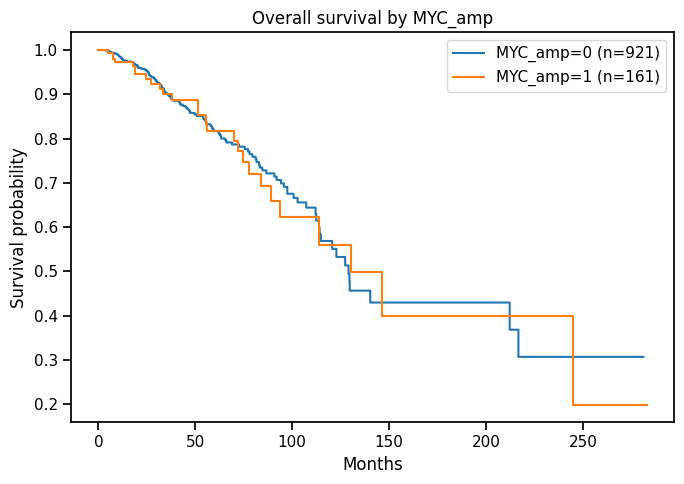

Log-rank p-value: 0.7946982890307844

PTEN_del


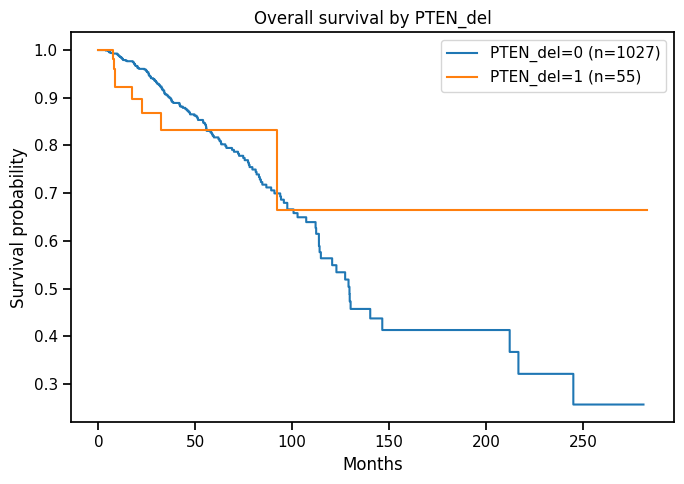

Log-rank p-value: 0.7200729823154712

RB1_del


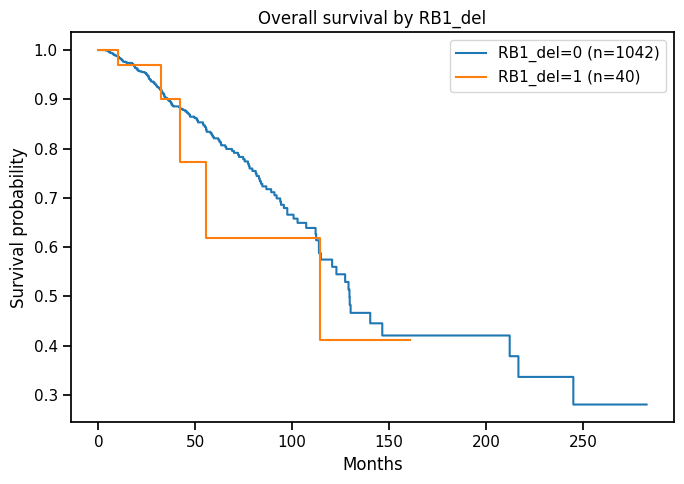

Log-rank p-value: 0.7666502654658667


In [12]:
selected_alterations = [
    "TP53_mut",
    "PIK3CA_mut",
    "ERBB2_amp",
    "CCND1_amp",
    "MYC_amp",
    "PTEN_del",
    "RB1_del",
]

for alt in selected_alterations:
    if alt in df.columns and {"OS_MONTHS", "OS_EVENT"}.issubset(df.columns):
        print(f"\n{alt}")
        plot_binary_km(
            df=df,
            duration_col="OS_MONTHS",
            event_col="OS_EVENT",
            alteration_col=alt,
            title=f"Overall survival by {alt}",
            filename=f"overall_survival_by_{alt}.png",
            min_group_size=20,
        )


TP53_mut


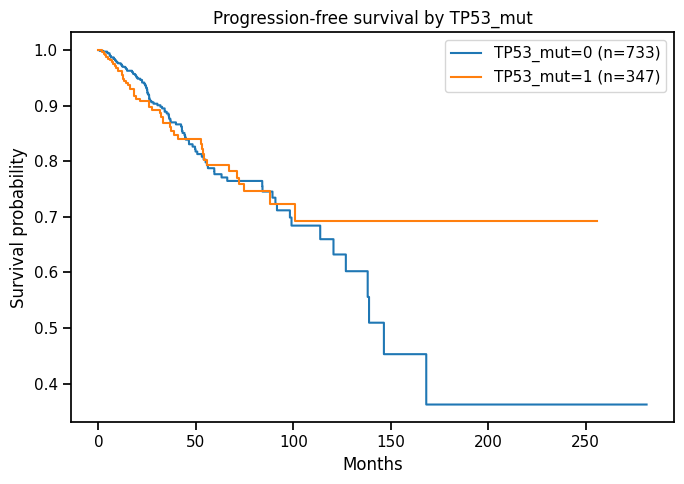

Log-rank p-value: 0.8863509070804078

PIK3CA_mut


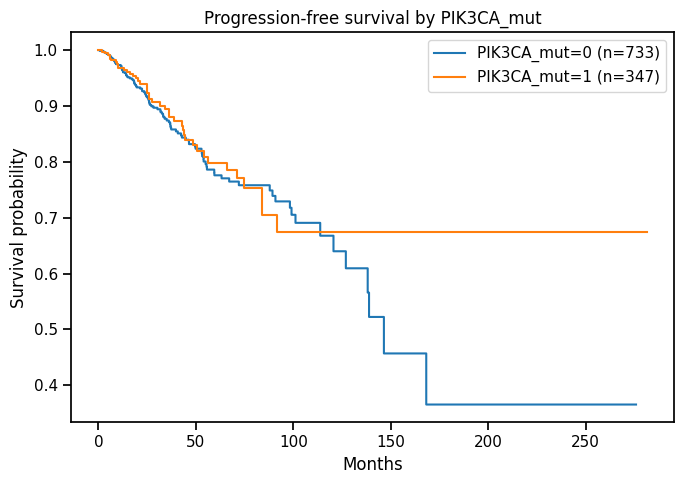

Log-rank p-value: 0.5853395215384926

ERBB2_amp


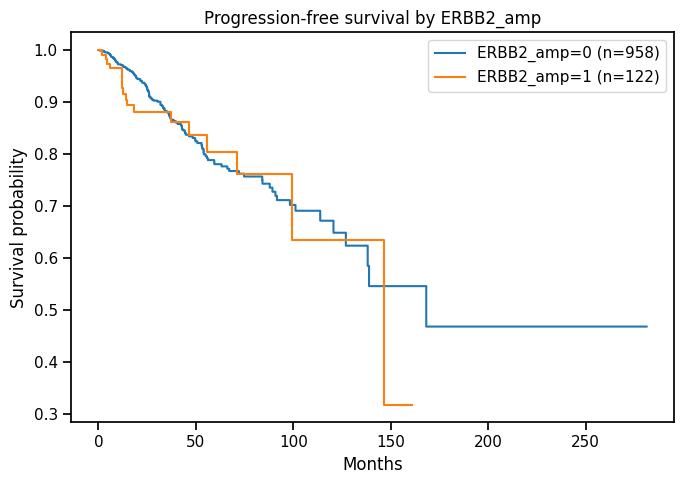

Log-rank p-value: 0.4955584254996397

CCND1_amp


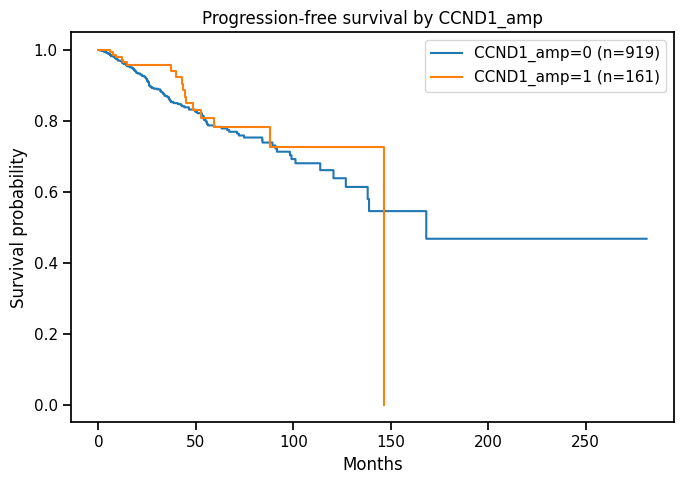

Log-rank p-value: 0.3934758189411046

MYC_amp


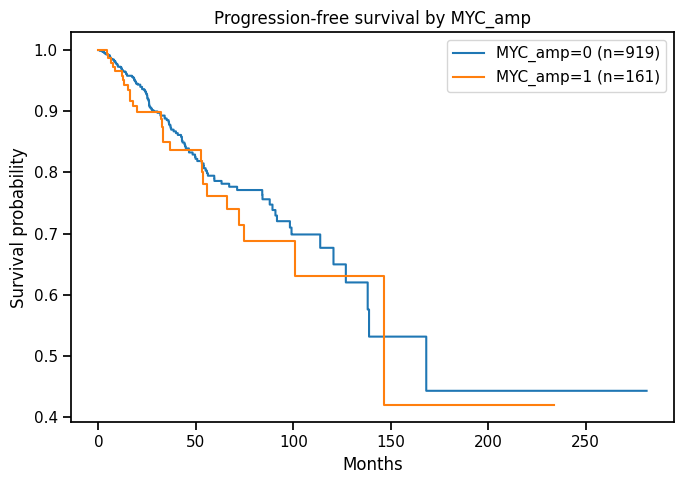

Log-rank p-value: 0.3953980470749191

PTEN_del


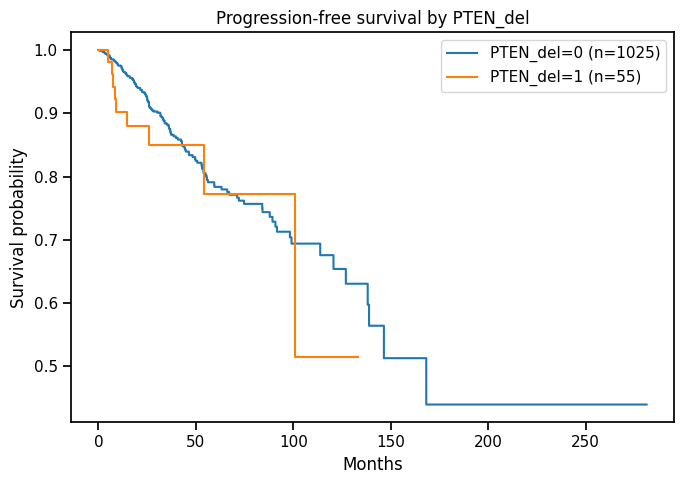

Log-rank p-value: 0.3744970565943746

RB1_del


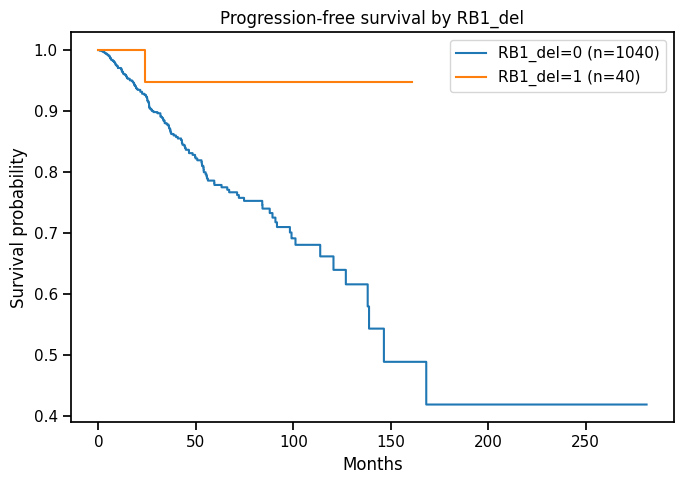

Log-rank p-value: 0.08991116124920279


In [13]:
for alt in selected_alterations:
    if alt in df.columns and {"PFS_MONTHS", "PFS_EVENT"}.issubset(df.columns):
        print(f"\n{alt}")
        plot_binary_km(
            df=df,
            duration_col="PFS_MONTHS",
            event_col="PFS_EVENT",
            alteration_col=alt,
            title=f"Progression-free survival by {alt}",
            filename=f"progression_free_survival_by_{alt}.png",
            min_group_size=20,
        )

In [14]:
summary_cols = [
    "SUBTYPE",
    "OS_MONTHS",
    "OS_EVENT",
    "PFS_MONTHS",
    "PFS_EVENT",
    "AGE",
]

summary_cols = [col for col in summary_cols if col in df.columns]

clinical_summary_by_subtype = (
    df[summary_cols]
    .groupby("SUBTYPE")
    .agg(["count", "median", "mean"])
)

display(clinical_summary_by_subtype)

clinical_summary_by_subtype.to_csv(
    TABLES_DIR / "clinical_summary_by_subtype.csv"
)

OS_MONTHS                       OS_EVENT                   \
                count     median       mean    count median      mean   
SUBTYPE                                                                 
BRCA_Basal        171  26.925732  44.075653      171    0.0  0.128655   
BRCA_Her2          78  21.353191  36.072945       78    0.0  0.192308   
BRCA_LumA         499  28.865437  42.913170      499    0.0  0.114228   
BRCA_LumB         197  24.788769  36.853890      197    0.0  0.157360   
BRCA_Normal        36  35.424269  43.703631       36    0.0  0.194444   

            PFS_MONTHS                       PFS_EVENT                    AGE  \
                 count     median       mean     count median      mean count   
SUBTYPE                                                                         
BRCA_Basal         171  24.986028  39.658878       171    0.0  0.146199   171   
BRCA_Her2           78  18.788835  32.395430        78    0.0  0.192308    78   
BRCA_LumA          498  26.596969  39.734042       499    0.0  0.114228   499   
BRCA_LumB          197  23.769603  35.146322       197    0.0  0.121827   197   
BRCA_Normal         36  33.944833  42.996789        36    0.0  0.194444    36   

                               
            median       mean  
SUBTYPE                        
BRCA_Basal    54.0  55.520468  
BRCA_Her2     56.5  58.192308  
BRCA_LumA     60.0  59.340681  
BRCA_LumB     58.0  58.685279  
BRCA_Normal   54.0  55.055556

## Interpretation

This notebook explores whether molecular subtypes and selected genomic alterations are associated with clinical outcomes in TCGA-BRCA.

Kaplan-Meier curves are used to compare overall survival and progression-free survival across subtypes and selected driver events.

These analyses should be interpreted cautiously. TCGA is a retrospective cohort, treatment information may be incomplete, follow-up differs between patients, and molecular groups have unequal sample sizes. Therefore, these results are hypothesis-generating rather than clinically validated prognostic biomarkers.

The main value of this notebook is to show how clinical metadata can be integrated with transcriptomic subtype annotations and genomic alteration data in a translational oncology workflow.